# Modelo Pregunta 2 - Regresión MLP
## ¿Podemos predecir el puntaje global ICFES según el perfil familiar, socioeconómico y del colegio?
**Rol:** Ciencia de datos  
**Integrante:** Danna Isabella Gómez Lozano

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import mlflow
import mlflow.keras

In [8]:
print(tf.__version__)

2.21.0


In [9]:
columnas_p2 = [
    'PUNT_GLOBAL',
    'ESTU_GENERO',
    'COLE_AREA_UBICACION',
    'COLE_BILINGUE',
    'COLE_GENERO',
    'COLE_MCPIO_UBICACION',
    'FAMI_CUARTOSHOGAR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_PERSONASHOGAR',
    'FAMI_TIENEAUTOMOVIL',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENELAVADORA',
    'PERIODO'
]

df = pd.read_csv('../df_filtrado.csv.zip', 
                 compression='zip', 
                 usecols=columnas_p2)

print(f"Datos cargados: {df.shape[0]:,} filas x {df.shape[1]} columnas ✅")
print(f"Memoria usada: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"\nPrimeras filas:")
df.head()

Datos cargados: 470,818 filas x 16 columnas ✅
Memoria usada: 412.2 MB

Primeras filas:


,PERIODO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_GENERO,COLE_MCPIO_UBICACION,ESTU_GENERO,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PUNT_GLOBAL
0,20224,URBANO,N,MIXTO,GRANADA,F,Dos,Ninguno,Ninguno,Estrato 1,5 a 6,No,No,No,No,196.0
1,20224,URBANO,N,MIXTO,CHOACHÍ,M,Tres,Secundaria (Bachillerato) incompleta,Primaria completa,Estrato 1,3 a 4,No,Si,Si,Si,258.0
2,20224,URBANO,NaN,MIXTO,SOACHA,M,NaN,Técnica o tecnológica completa,Secundaria (Bachillerato) completa,Estrato 2,NaN,NaN,NaN,Si,NaN,285.0
3,20224,URBANO,N,MIXTO,SOACHA,F,Tres,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,3 a 4,No,Si,Si,Si,302.0
4,20224,RURAL,N,MIXTO,SASAIMA,M,Dos,Técnica o tecnológica completa,No Aplica,Estrato 2,1 a 2,No,No,Si,Si,241.0


In [10]:
# Eliminar nulos
df = df.dropna()
print(f"Filas después de limpiar nulos: {df.shape[0]:,}")

# Codificar variables categóricas con OrdinalEncoder
# (respeta el orden natural mejor que LabelEncoder)
cols_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nColumnas categóricas: {cols_categoricas}")

encoder = OrdinalEncoder()
df[cols_categoricas] = encoder.fit_transform(df[cols_categoricas])

# Separar variable objetivo y predictoras
X = df.drop(columns=['PUNT_GLOBAL'])
y = df['PUNT_GLOBAL']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nEstadísticas de PUNT_GLOBAL:")
print(y.describe().round(2))

Filas después de limpiar nulos: 231,424

Columnas categóricas: ['COLE_AREA_UBICACION', 'COLE_BILINGUE', 'COLE_GENERO', 'COLE_MCPIO_UBICACION', 'ESTU_GENERO', 'FAMI_CUARTOSHOGAR', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_ESTRATOVIVIENDA', 'FAMI_PERSONASHOGAR', 'FAMI_TIENEAUTOMOVIL', 'FAMI_TIENECOMPUTADOR', 'FAMI_TIENEINTERNET', 'FAMI_TIENELAVADORA']

X shape: (231424, 15)
y shape: (231424,)

Estadísticas de PUNT_GLOBAL:
count    231424.00
mean        260.41
std          46.00
min          17.00
25%         227.00
50%         258.00
75%         291.00
max         483.00
Name: PUNT_GLOBAL, dtype: float64


In [11]:
# División 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas")
print(f"Prueba: {X_test.shape[0]:,} filas")

# Escalar variables predictoras
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nDatos escalados ✅")

Entrenamiento: 185,139 filas
Prueba: 46,285 filas

Datos escalados ✅


In [12]:
# Configurar MLflow
mlflow.set_experiment("Prediccion_PUNT_GLOBAL_P2")

with mlflow.start_run(run_name="Experimento_1_baseline"):
    
    # Arquitectura del modelo
    model1 = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1)  # salida continua para regresión
    ])
    
    model1.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Early stopping para evitar sobreajuste
    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    
    # Entrenar
    history1 = model1.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=512,
        callbacks=[early_stop],
        verbose=1
    )
    
    # Evaluar
    y_pred1 = model1.predict(X_test_scaled).flatten()
    mae1 = mean_absolute_error(y_test, y_pred1)
    rmse1 = np.sqrt(mean_squared_error(y_test, y_pred1))
    r2_1 = r2_score(y_test, y_pred1)
    
    # Registrar en MLflow
    mlflow.log_param("capas", "64-32-1")
    mlflow.log_param("activacion", "relu")
    mlflow.log_param("batch_size", 512)
    mlflow.log_metric("MAE", mae1)
    mlflow.log_metric("RMSE", rmse1)
    mlflow.log_metric("R2", r2_1)
    
    print(f"\n📊 Resultados Experimento 1:")
    print(f"MAE:  {mae1:.2f}")
    print(f"RMSE: {rmse1:.2f}")
    print(f"R²:   {r2_1:.4f}")

2026/05/21 23:00:59 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/21 23:00:59 INFO mlflow.store.db.utils: Updating database tables
2026/05/21 23:00:59 INFO mlflow.tracking.fluent: Experiment with name 'Prediccion_PUNT_GLOBAL_P2' does not exist. Creating a new experiment.


Epoch 1/50


/opt/anaconda3/envs/proyecto2/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 691us/step - loss: 39553.5469 - mae: 179.0407 - val_loss: 4078.6812 - val_mae: 51.1558
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - loss: 2746.2986 - mae: 41.6780 - val_loss: 2292.3035 - val_mae: 38.3093
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 511us/step - loss: 2141.3635 - mae: 37.1104 - val_loss: 2043.8650 - val_mae: 36.3501
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - loss: 1981.8462 - mae: 35.7784 - val_loss: 1942.2955 - val_mae: 35.4842
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 519us/step - loss: 1904.5414 - mae: 35.1074 - val_loss: 1884.6670 - val_mae: 34.9759
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 516us/step - loss: 1856.0107 - mae: 34.6757 - val_loss: 1847.2972 - val_mae: 34.6369
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 505us/step - loss: 1822.0233 - mae: 34.3673 - val_loss: 1818.4072 - val_mae: 34.3597
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 1795.6151 - mae: 34.1270 - val_loss: 1796.2682 - va

In [13]:
with mlflow.start_run(run_name="Experimento_2_profunda"):
    
    model2 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model2.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    
    history2 = model2.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=512,
        callbacks=[early_stop],
        verbose=1
    )
    
    y_pred2 = model2.predict(X_test_scaled).flatten()
    mae2 = mean_absolute_error(y_test, y_pred2)
    rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
    r2_2 = r2_score(y_test, y_pred2)
    
    mlflow.log_param("capas", "128-64-32-1")
    mlflow.log_param("activacion", "relu")
    mlflow.log_param("batch_size", 512)
    mlflow.log_metric("MAE", mae2)
    mlflow.log_metric("RMSE", rmse2)
    mlflow.log_metric("R2", r2_2)
    
    print(f"\n📊 Resultados Experimento 2:")
    print(f"MAE:  {mae2:.2f}")
    print(f"RMSE: {rmse2:.2f}")
    print(f"R²:   {r2_2:.4f}")

Epoch 1/50


/opt/anaconda3/envs/proyecto2/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 18742.2715 - mae: 97.8663 - val_loss: 2021.6785 - val_mae: 36.0938
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - loss: 1919.8066 - mae: 35.1996 - val_loss: 1864.5077 - val_mae: 34.7811
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - loss: 1819.0422 - mae: 34.3278 - val_loss: 1800.1460 - val_mae: 34.1734
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - loss: 1769.9592 - mae: 33.8791 - val_loss: 1770.5977 - val_mae: 33.9144
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - loss: 1745.3082 - mae: 33.6563 - val_loss: 1753.2202 - val_mae: 33.7649
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 781us/step - loss: 1729.7640 - mae: 33.5076 - val_loss: 1742.9075 - val_mae: 33.6422
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 848us/step - loss: 1721.5059 - mae: 33.4360 - val_loss: 1737.9310 - val_mae: 33.5828
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 779us/step - loss: 1714.4833 - mae: 33.3602 - val_loss: 1731.6953 - val_m

In [14]:
with mlflow.start_run(run_name="Experimento_3_regularizacion"):
    
    model3 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    
    model3.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(patience=5, restore_best_weights=True)
    
    history3 = model3.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=512,
        callbacks=[early_stop],
        verbose=1
    )
    
    y_pred3 = model3.predict(X_test_scaled).flatten()
    mae3 = mean_absolute_error(y_test, y_pred3)
    rmse3 = np.sqrt(mean_squared_error(y_test, y_pred3))
    r2_3 = r2_score(y_test, y_pred3)
    
    mlflow.log_param("capas", "128-64-32-1")
    mlflow.log_param("activacion", "relu")
    mlflow.log_param("batch_size", 512)
    mlflow.log_param("dropout", "0.3-0.2")
    mlflow.log_param("batch_norm", True)
    mlflow.log_metric("MAE", mae3)
    mlflow.log_metric("RMSE", rmse3)
    mlflow.log_metric("R2", r2_3)
    
    print(f"\n📊 Resultados Experimento 3:")
    print(f"MAE:  {mae3:.2f}")
    print(f"RMSE: {rmse3:.2f}")
    print(f"R²:   {r2_3:.4f}")

Epoch 1/50


/opt/anaconda3/envs/proyecto2/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 44143.7891 - mae: 195.9439 - val_loss: 11040.1904 - val_mae: 89.0569
Epoch 2/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3481.3108 - mae: 46.5933 - val_loss: 1790.1091 - val_mae: 34.0112
Epoch 3/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2424.8274 - mae: 39.3973 - val_loss: 1754.0139 - val_mae: 33.6977
Epoch 4/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2363.8994 - mae: 38.9188 - val_loss: 1751.7617 - val_mae: 33.6798
Epoch 5/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2328.8354 - mae: 38.6307 - val_loss: 1769.6899 - val_mae: 33.7798
Epoch 6/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2291.0037 - mae: 38.3317 - val_loss: 1742.6871 - val_mae: 33.6442
Epoch 7/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2246.4260 - mae: 38.0202 - val_loss: 1757.1854 - val_mae: 33.7367
Epoch 8/50
290/290 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2221.2000 - mae: 37.7571 - val_loss: 1758.9932 - val_mae: 33.7484


In [15]:
# Guardar modelo ganador (Experimento 1)
model1.save('../modelos/modelo_p2.keras')

# Guardar el scaler para usarlo en el tablero
import joblib
joblib.dump(scaler, '../modelos/scaler_p2.pkl')
joblib.dump(encoder, '../modelos/encoder_p2.pkl')

print("Modelo y transformadores guardados ✅")

Modelo y transformadores guardados ✅


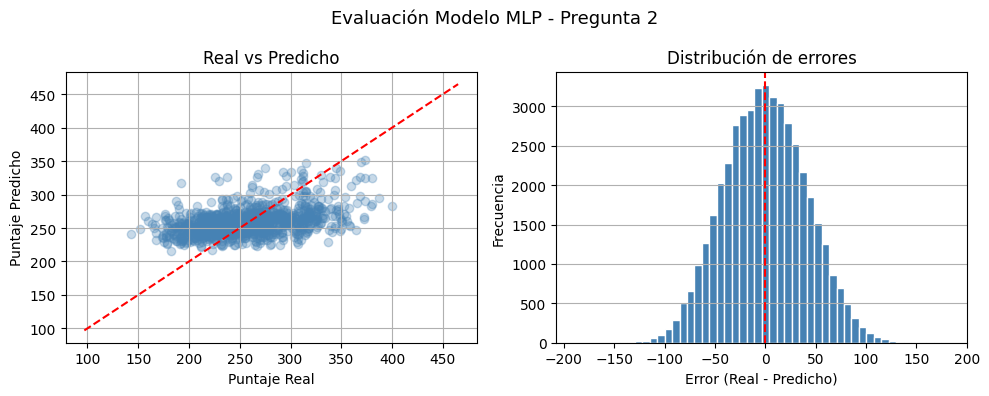

In [16]:
# Comparación real vs predicho
plt.figure(figsize=(10, 4))

# Gráfica 1 - Real vs Predicho
plt.subplot(1, 2, 1)
plt.scatter(y_test[:1000], y_pred1[:1000], alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Puntaje Real')
plt.ylabel('Puntaje Predicho')
plt.title('Real vs Predicho')
plt.grid(True)

# Gráfica 2 - Distribución de errores
errores = y_test - y_pred1
plt.subplot(1, 2, 2)
plt.hist(errores, bins=50, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Error (Real - Predicho)')
plt.ylabel('Frecuencia')
plt.title('Distribución de errores')
plt.grid(True, axis='y')

plt.suptitle('Evaluación Modelo MLP - Pregunta 2', fontsize=13)
plt.tight_layout()
plt.show()
